In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

df = pd.read_csv("/content/emails.csv")  # limit for performance
df.head()               #Loading Emails into Pandas

#import mailbox
#import pandas as pd

#mbox = mailbox.mbox("emails.mbox")

#data = []

#for message in mbox:
 #   data.append({
  #      "from": message["from"],
   #     "to": message["to"],
    #    "subject": message["subject"],
     #   "date": message["date"],
      #  "body": message.get_payload()
    #})

#df = pd.DataFrame(data)
#print(df.head())

,sender,receiver,subject,length,has_attachment,date
0,alice@gmail.com,bob@gmail.com,Meeting update,120,0,10-01-25
1,boss@company.com,alice@gmail.com,Project deadline,350,1,11-01-25
2,newsletter@shop.com,alice@gmail.com,Big Sale Offer,200,0,12-01-25
3,friend@yahoo.com,alice@gmail.com,Weekend Plan,80,0,13-01-25
4,boss@company.com,alice@gmail.com,Important Notice,400,1,14-01-25


In [ ]:
print("Shape:", df.shape)
df.info()
df.describe(include='all')

Shape: (10, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   sender          10 non-null     object
 1   receiver        10 non-null     object
 2   subject         10 non-null     object
 3   length          10 non-null     int64 
 4   has_attachment  10 non-null     int64 
 5   date            10 non-null     object
dtypes: int64(2), object(4)
memory usage: 612.0+ bytes


,sender,receiver,subject,length,has_attachment,date
count,10,10,10,10.000000,10.000000,10
unique,6,2,10,NaN,NaN,10
top,boss@company.com,alice@gmail.com,Meeting update,NaN,NaN,10-01-25
freq,3,9,1,NaN,NaN,1
mean,NaN,NaN,NaN,212.000000,0.400000,NaN
std,NaN,NaN,NaN,110.232078,0.516398,NaN
min,NaN,NaN,NaN,80.000000,0.000000,NaN
25%,NaN,NaN,NaN,127.500000,0.000000,NaN
50%,NaN,NaN,NaN,190.000000,0.000000,NaN
75%,NaN,NaN,NaN,287.500000,1.000000,NaN


In [ ]:
# Convert date safely
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows where important values are missing
df = df.dropna(subset=['date', 'sender'])

# Fill missing text columns
df['subject'] = df['subject'].fillna("")
print(df)

                sender         receiver             subject  length  \
0      alice@gmail.com    bob@gmail.com      Meeting update     120   
1     boss@company.com  alice@gmail.com    Project deadline     350   
2  newsletter@shop.com  alice@gmail.com      Big Sale Offer     200   
3     friend@yahoo.com  alice@gmail.com        Weekend Plan      80   
4     boss@company.com  alice@gmail.com    Important Notice     400   
5        spam@spam.com  alice@gmail.com       You won prize     150   
6       hr@company.com  alice@gmail.com  Interview Schedule     250   
7  newsletter@shop.com  alice@gmail.com     Discount Coupon     180   
8     friend@yahoo.com  alice@gmail.com        Party Invite      90   
9     boss@company.com  alice@gmail.com       Weekly Report     300   

   has_attachment       date  
0               0 2025-10-01  
1               1 2025-11-01  
2               0 2025-12-01  
3               0 2025-01-13  
4               1 2025-01-14  
5               0 2025-01-15  
6

/tmp/ipykernel_907/3049839178.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [ ]:
# Date-based features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour   # will be 0 since no time in dataset
df['weekday'] = df['date'].dt.day_name()

# Email length (already exists, but renaming for clarity)
df['email_length'] = df['length']

# Extract domain from sender
df['domain'] = df['sender'].str.extract(r'@([\w\.-]+)')
print(df)

                sender         receiver             subject  length  \
0      alice@gmail.com    bob@gmail.com      Meeting update     120   
1     boss@company.com  alice@gmail.com    Project deadline     350   
2  newsletter@shop.com  alice@gmail.com      Big Sale Offer     200   
3     friend@yahoo.com  alice@gmail.com        Weekend Plan      80   
4     boss@company.com  alice@gmail.com    Important Notice     400   
5        spam@spam.com  alice@gmail.com       You won prize     150   
6       hr@company.com  alice@gmail.com  Interview Schedule     250   
7  newsletter@shop.com  alice@gmail.com     Discount Coupon     180   
8     friend@yahoo.com  alice@gmail.com        Party Invite      90   
9     boss@company.com  alice@gmail.com       Weekly Report     300   

   has_attachment       date  year  month  day  hour    weekday  email_length  \
0               0 2025-10-01  2025     10    1     0  Wednesday           120   
1               1 2025-11-01  2025     11    1     0   S

In [ ]:
len(df)                           #no. of emails

10

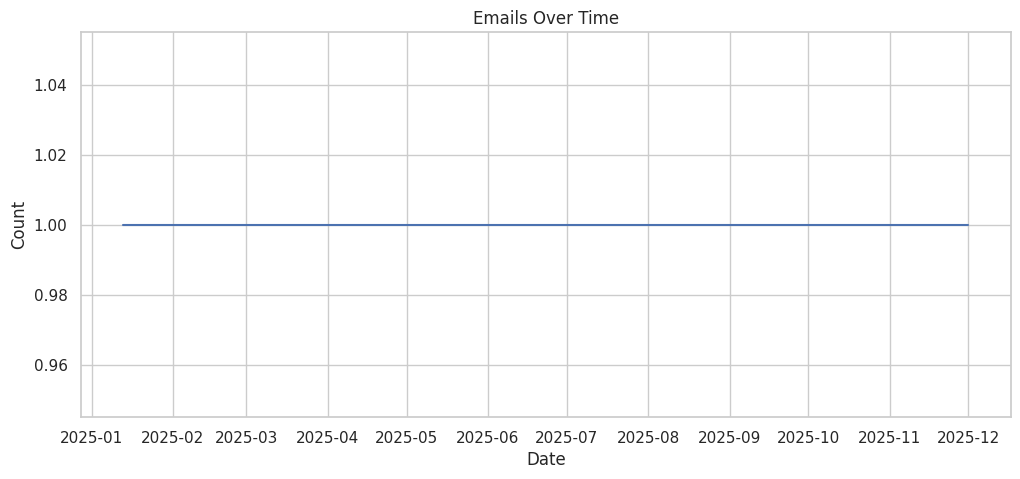

In [ ]:
#emails over time - Detect inactivity phases, Identify peak communication periods
plt.figure(figsize=(12,5))
df.groupby(df['date'].dt.date).size().plot()
plt.title("Emails Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

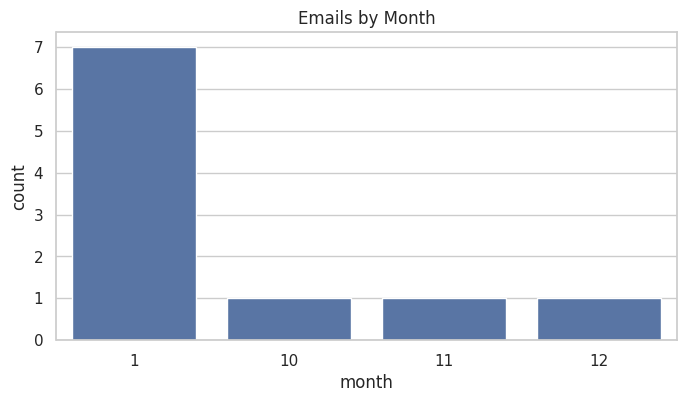

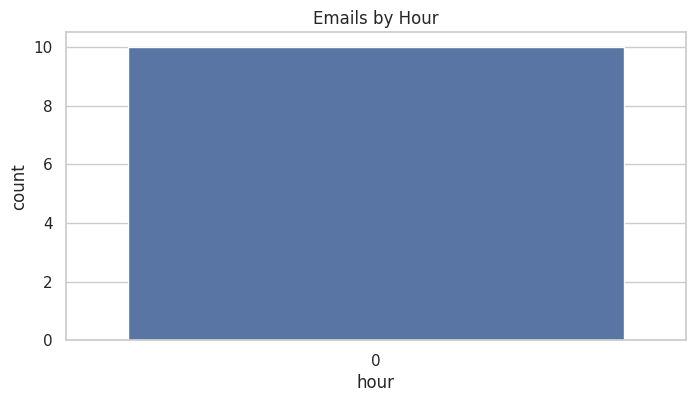

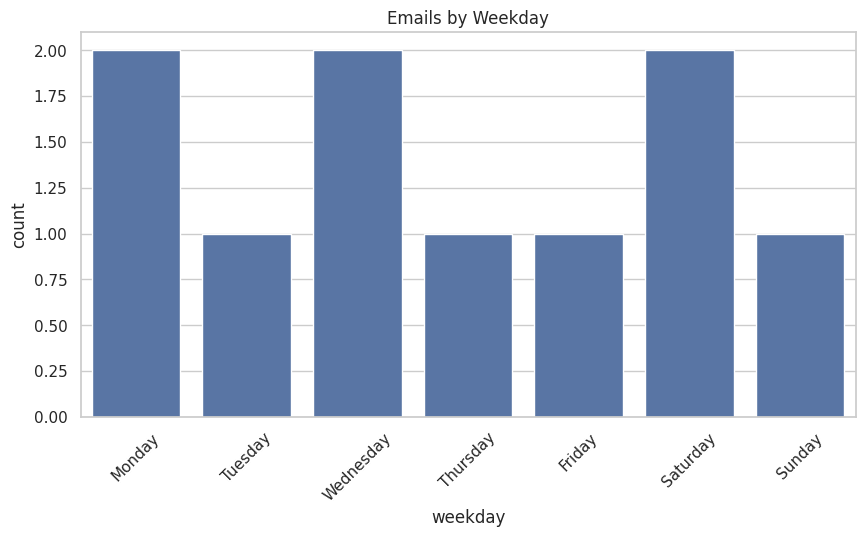

In [ ]:
#Seasonal trends
plt.figure(figsize=(8,4))
sns.countplot(x='month', data=df)
plt.title("Emails by Month")
plt.show()

#When we are most active
plt.figure(figsize=(8,4))
sns.countplot(x='hour', data=df)
plt.title("Emails by Hour")
plt.show()

#email by weekday
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,5))
sns.countplot(x='weekday', data=df, order=order)
plt.xticks(rotation=45)
plt.title("Emails by Weekday")
plt.show()

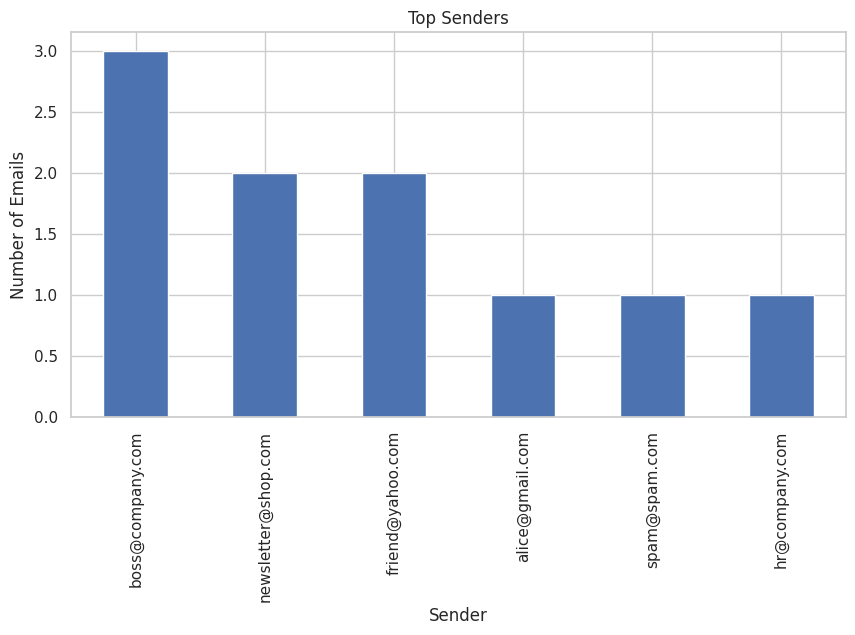

sender
boss@company.com       3
newsletter@shop.com    2
friend@yahoo.com       2
alice@gmail.com        1
spam@spam.com          1
hr@company.com         1
Name: count, dtype: int64


In [ ]:
# Frequent contacts (Top senders)
top_senders = df['sender'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_senders.plot(kind='bar')
plt.title("Top Senders")
plt.xlabel("Sender")
plt.ylabel("Number of Emails")
plt.show()

print(top_senders)

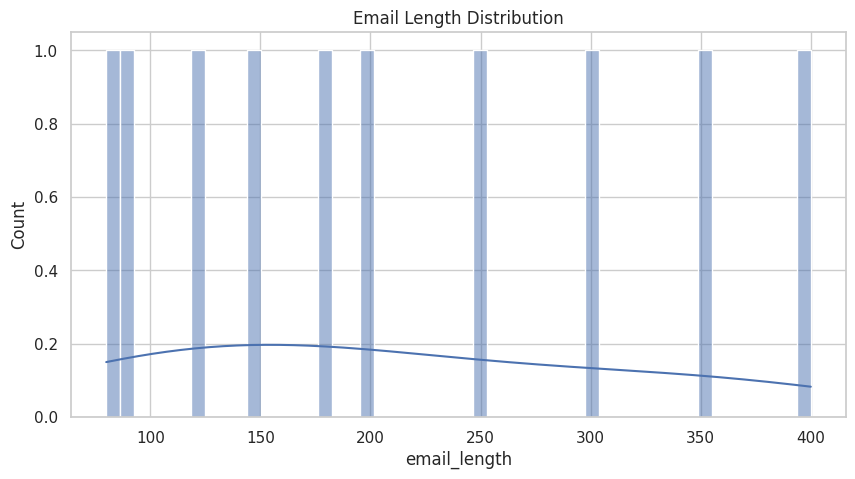

In [ ]:
# Email Length Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['email_length'], bins=50, kde=True)
plt.title("Email Length Distribution")
plt.show()

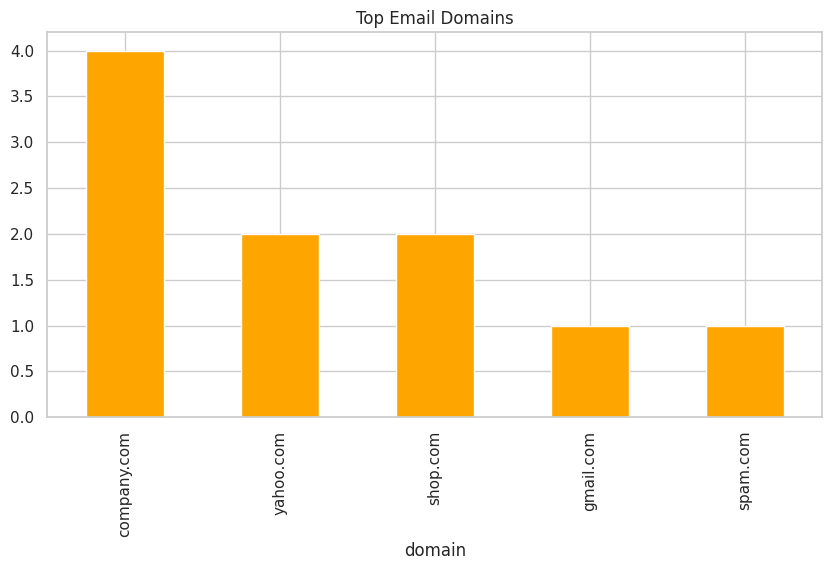

domain
company.com    4
yahoo.com      2
shop.com       2
gmail.com      1
spam.com       1
Name: count, dtype: int64


In [ ]:
#top email domains
top_domains = df['domain'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_domains.plot(kind='bar', color='orange')
plt.title("Top Email Domains")
plt.show()

print(top_domains)

Top 20 Words:
meeting 1
update 1
project 1
deadline 1
big 1
sale 1
offer 1
weekend 1
plan 1
important 1
notice 1
you 1
won 1
prize 1
interview 1
schedule 1
discount 1
coupon 1
party 1
invite 1


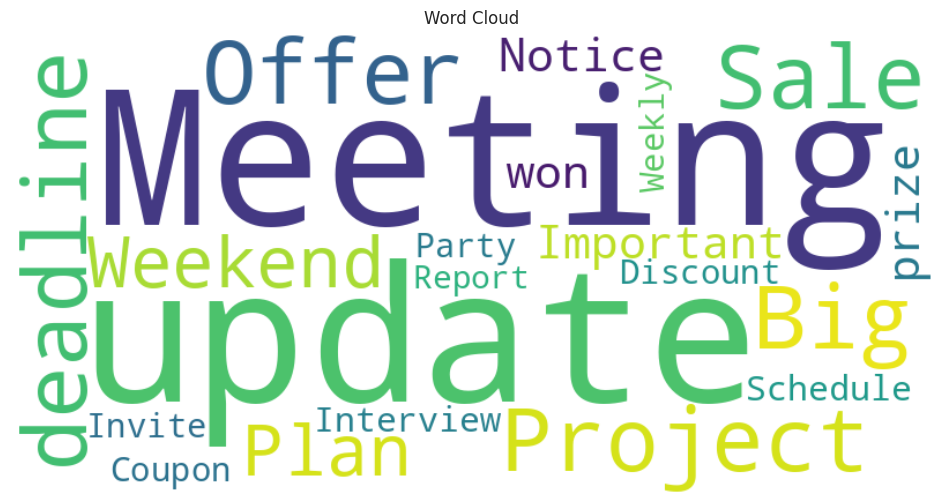

In [ ]:
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Email length (already given, so optional)
df['email_length'] = df['length']

# Combine all subject text
text = " ".join(df['subject'].astype(str))

# Most common words
words = re.findall(r'\w+', text.lower())
common_words = Counter(words).most_common(20)

print("Top 20 Words:")
for word, count in common_words:
    print(word, count)

# Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [ ]:
# Extract domain from sender email
df['domain'] = df['sender'].str.extract(r'@([\w\.-]+)')

# Domain frequency (Top 10)
domain_counts = df['domain'].value_counts().head(10)

print(domain_counts)

domain
company.com    4
yahoo.com      2
shop.com       2
gmail.com      1
spam.com       1
Name: count, dtype: int64


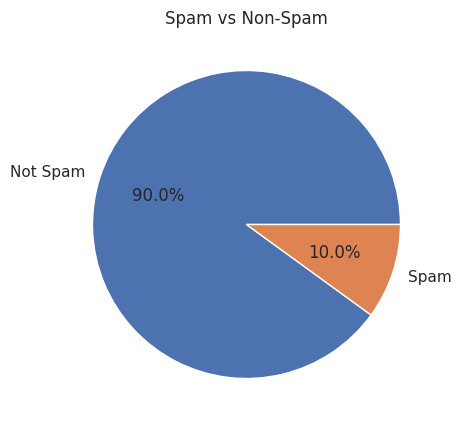

is_spam
False    9
True     1
Name: count, dtype: int64


In [ ]:
# Spam detection using subject keywords
df['is_spam'] = df['subject'].str.contains(
    "free|win|offer|money", case=False, na=False )

# Count spam vs non-spam
spam_counts = df['is_spam'].value_counts()

# Pie chart
plt.figure(figsize=(5,5))
spam_counts.plot(kind='pie', autopct='%1.1f%%', labels=['Not Spam', 'Spam'])
plt.title("Spam vs Non-Spam")
plt.ylabel("")
plt.show()

# Print result
print(spam_counts)